Basic settings

In [1]:
from utgc.runner import EnsembleRunner
tag = "SA"

Election settings

In [2]:
runner = EnsembleRunner.from_config(f'output/{tag}/testrun/config.yaml')
runner = (runner
    .add_election_updaters(
        years=[2016, 2020, 2024],
        elections=['PRE','GOV','ATG','AUD','TRE'],
        parties_to_columns_override={
            "2024GOV":{"R1":"G24GOVRHEN","R2":"G24GOVNCLA"}
        }
    )
    .add_election_aggregator(
        "sb1011_data",
        ["2016PRE", "2016GOV", "2016ATG", "2016AUD", "2016TRE", "2020PRE", "2020GOV", "2020ATG", "2024PRE", "2024GOV", "2024ATG", "2024AUD", "2024TRE"],
        parties=["D", "R", "-"]
    )
    .add_election_metric_updaters(
        "sb1011_data",
        ["partisan_bias_utah", "partisan_bias", "mean_median", "efficiency_gap", "stdev_partisan_share", "majority_partisan_shares", "majority_seats"]
    )
)

Initializing runner from configuration: output/SA/testrun/config.yaml
Loaded 13126 segments from data/UT_capped_500.geojson
Loaded 4 districts from maps/US-House/2025_USH_Leg-C/2025_USH_Leg-C.shp
Projecting to EPSG:26912
Found 10740 nodes assigned to 254 incorporated municipalities
Assigning unique IDs to unincorporated nodes...
Assigned unique IDs to 2386 unincorporated nodes
Total unique MUNIIDs: 2640
  Graph built with 13126 nodes, 33567 edges
Population deviation tolerance: 0.100000%
Constraint: split max 2 muni
Constraint: max 0 multi-splits of muni
  Added locality split updater: 'ls_muni'
    Ignoring updater in output: 'ls_muni'
  Added split updater: 'split_muni'
  Added multi-split updater: 'muni_multi_splits'
Constraint: split max 3 county
Constraint: max 0 multi-splits of county
  Added locality split updater: 'ls_county'
    Ignoring updater in output: 'ls_county'
  Added split updater: 'split_county'
  Added multi-split updater: 'county_multi_splits'
Constraint: prevent s

In [3]:
# Set up visualization of sample maps
import os
import utgc.plotting as gcplt
import utgc.notebookhelper as nbh

munis, counties = nbh.load_boundaries_from_shapefiles()

runner = runner.add_runtime_callback(
    name="render_maps",
    frequency=10,
    action=lambda partition, step, output_dir: gcplt.visualize_partition(
        partition,
        step,
        os.path.join(output_dir, "maps"),
        counties=counties,
        municipalities=munis,
        split_munis_count=partition["split_muni"],
        split_counties_count=partition["split_county"],
    )
)

Loaded 29 counties from data/bounds/UtahCountyBoundaries/ut_cnty_2020_bound.shp
Loaded 259 municipalities from data/bounds/UtahMunicipalBoundaries/Municipalities.shp
Registered callback 'render_maps' (<lambda>) to run every 10 steps.


In [4]:
runner = runner.precondition(steps=100)
runner.run(
    name="ensemble",
    output_dir=f"output/{tag}/",
    num_steps=1000,
)

=== Preconditioning ===
Starting preconditioning...


100%|██████████| 100/100 [03:15<00:00,  1.96s/it]


  Preconditioning successful! All tolerances met.
=== MCMC ensemble ===
Configured short_bursts run with 100 bursts of 10 steps each
Running Markov chain...


100%|██████████| 1000/1000 [55:03<00:00,  3.30s/it] 


In [5]:
import json

comparison_maps = {
    "Map C": runner.compute_metrics_for_map(
        "maps/US-House/2025_USH_Leg-C/2025_USH_Leg-C.shp"
    ),
    "Plaintiff 1": runner.compute_metrics_for_map(
        "maps/US-House/2025_USH_Plaintiff-1/2025_USH_Plaintiff-1.shp"
    ),
    "Plaintiff 2": runner.compute_metrics_for_map(
        "maps/US-House/2025_USH_Plaintiff-2/2025_USH_Plaintiff-2.shp"
    ),
    "2021 Enacted": runner.compute_metrics_for_map(
        "maps/US-House/2021_USH_Enacted/2021_USH_Enacted.shp"
    ),
    "UIRC Orange": runner.compute_metrics_for_map(
        "maps/US-House/2021_USH_UIRC-Orange/2021_USH_UIRC-Orange.shp"
    ),
    "UIRC Purple": runner.compute_metrics_for_map(
        "maps/US-House/2021_USH_UIRC-Purple/2021_USH_UIRC-Purple.shp"
    ),
    "UIRC Public": runner.compute_metrics_for_map(
        "maps/US-House/2021_USH_UIRC-Public/2021_USH_UIRC-Public.shp"
    ),
}

with open(f"output/{tag}/ensemble/comparison_maps.json", "w") as f:
    json.dump(comparison_maps, f, indent=2)

In [6]:
import json

if "comparison_maps" not in locals():
    with open(f"output/{tag}/ensemble/comparison_maps.json", "r") as f:
        comparison_maps = json.load(f)

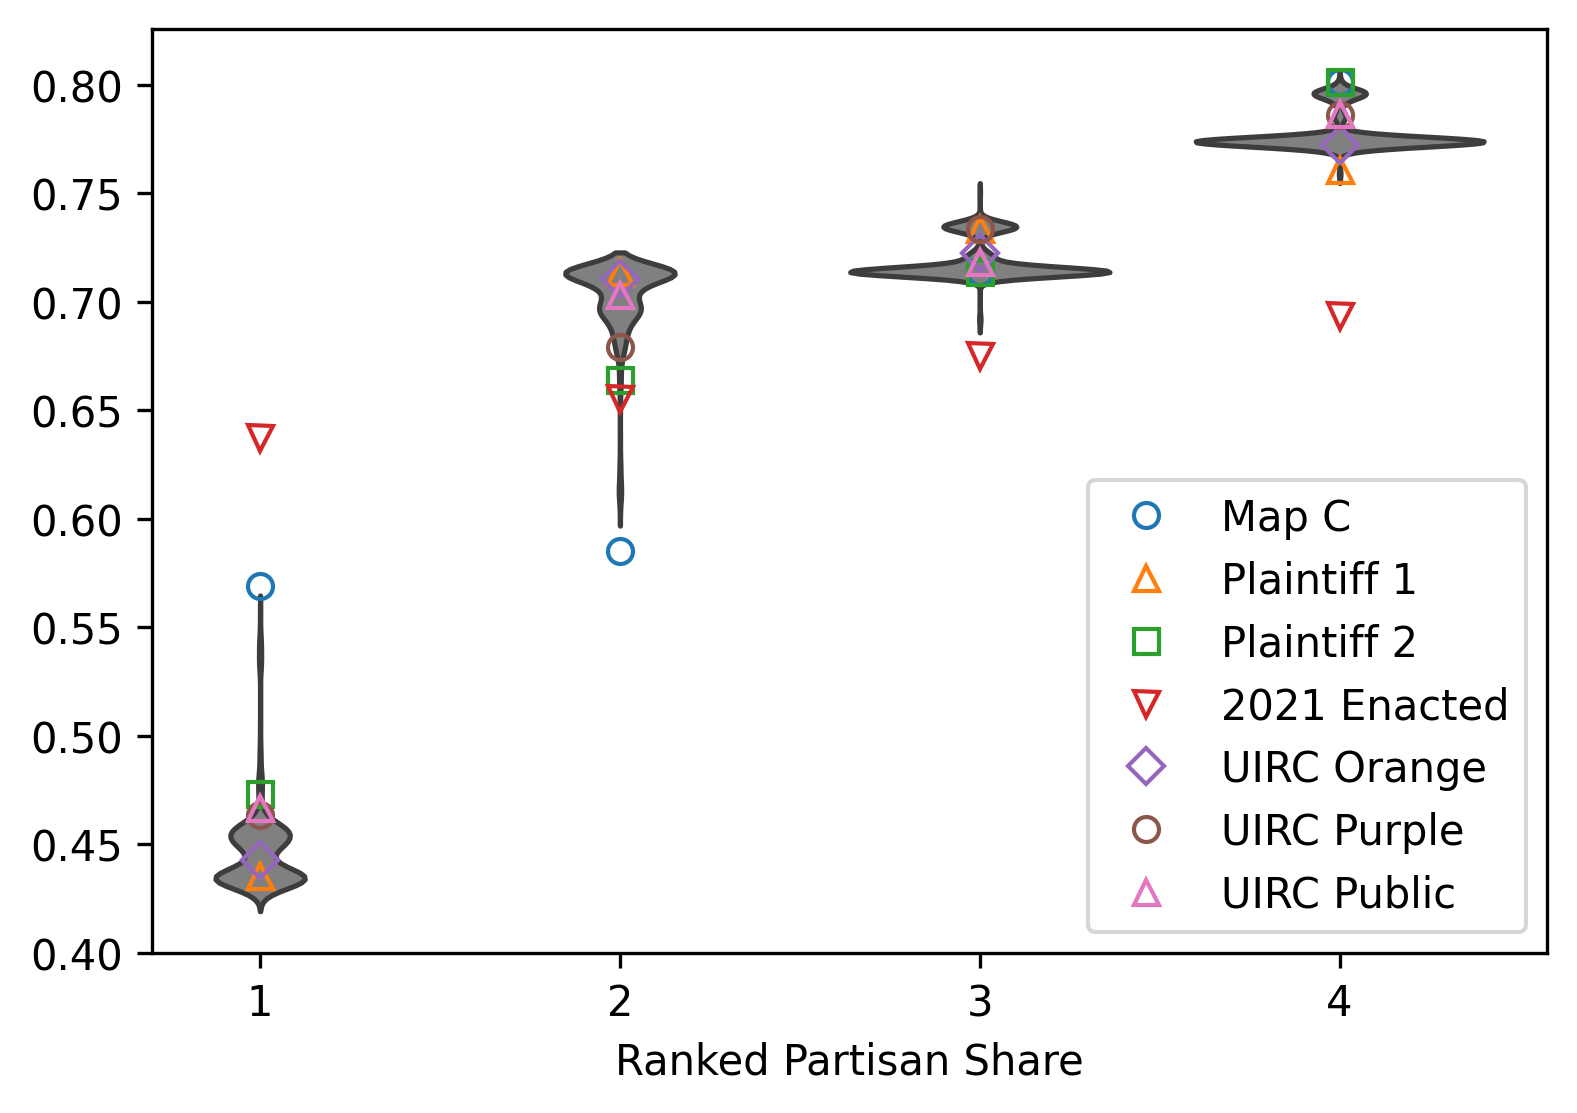

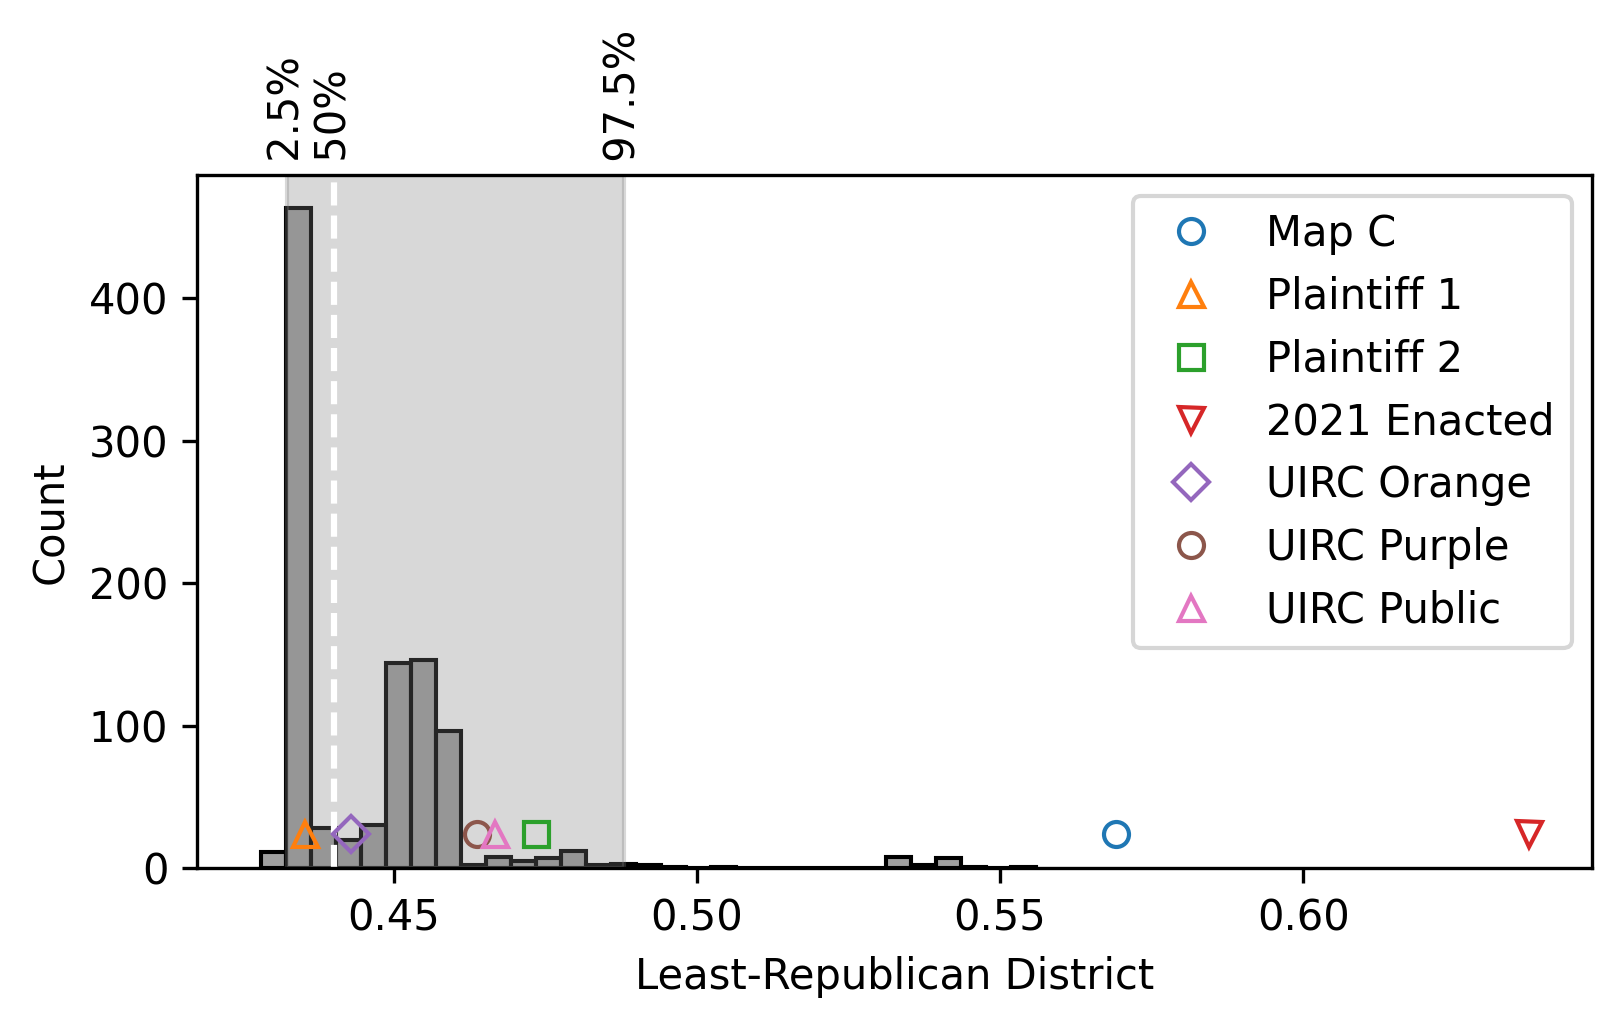

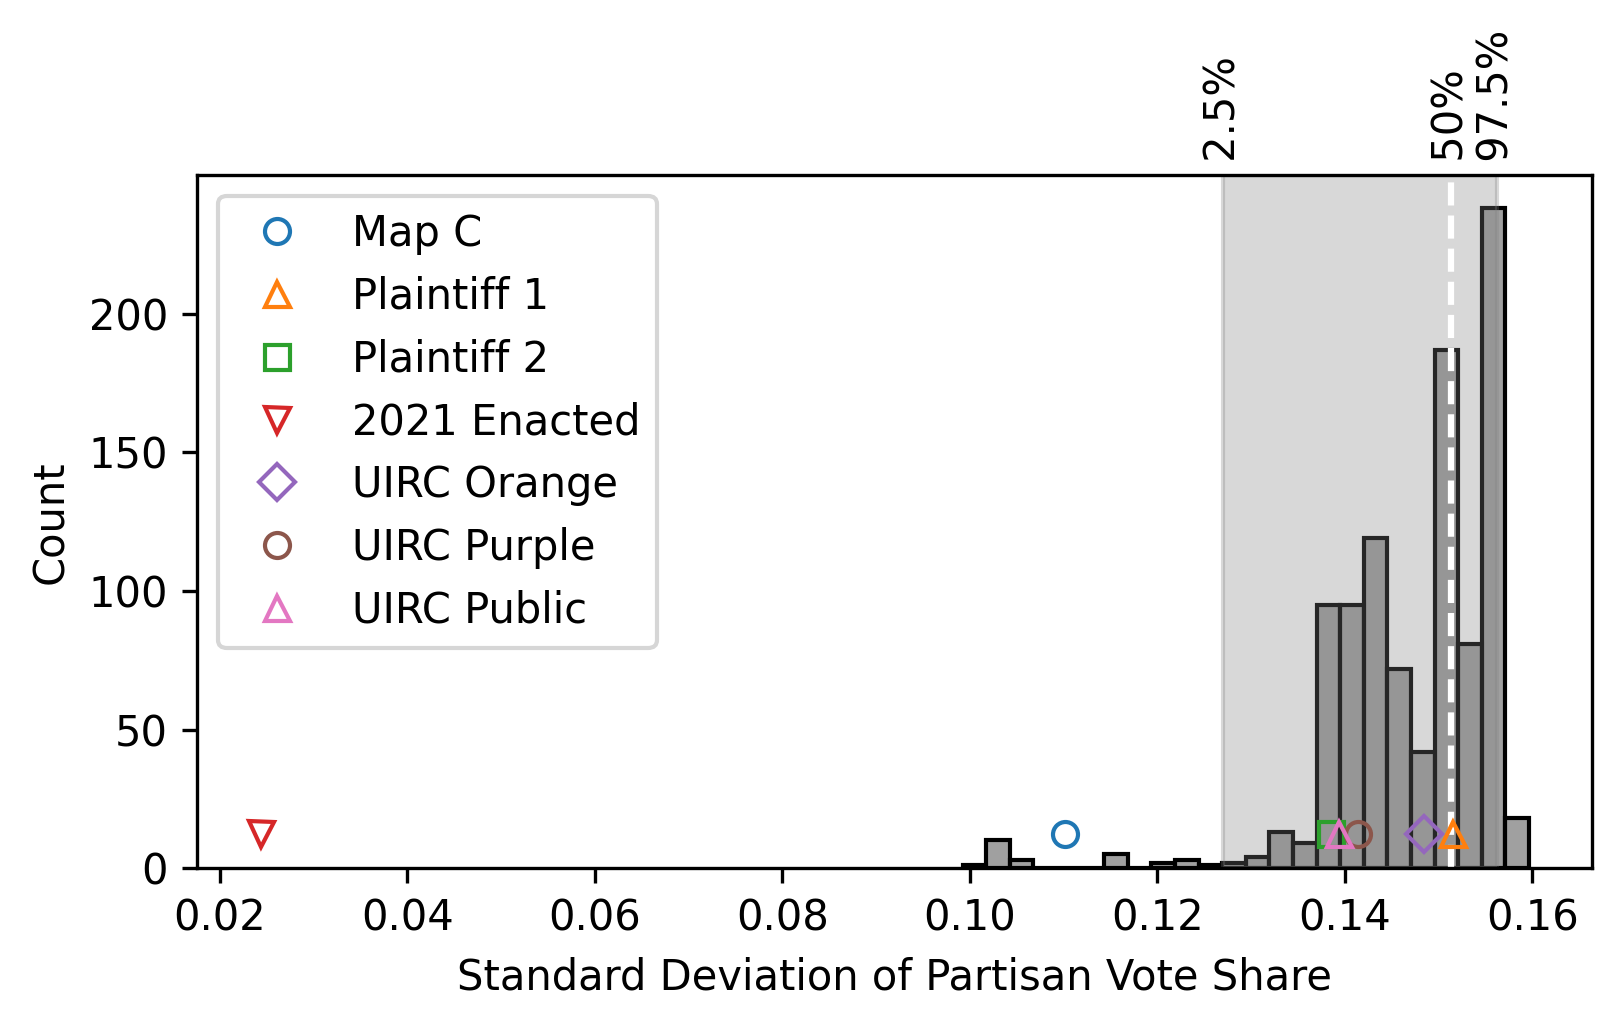

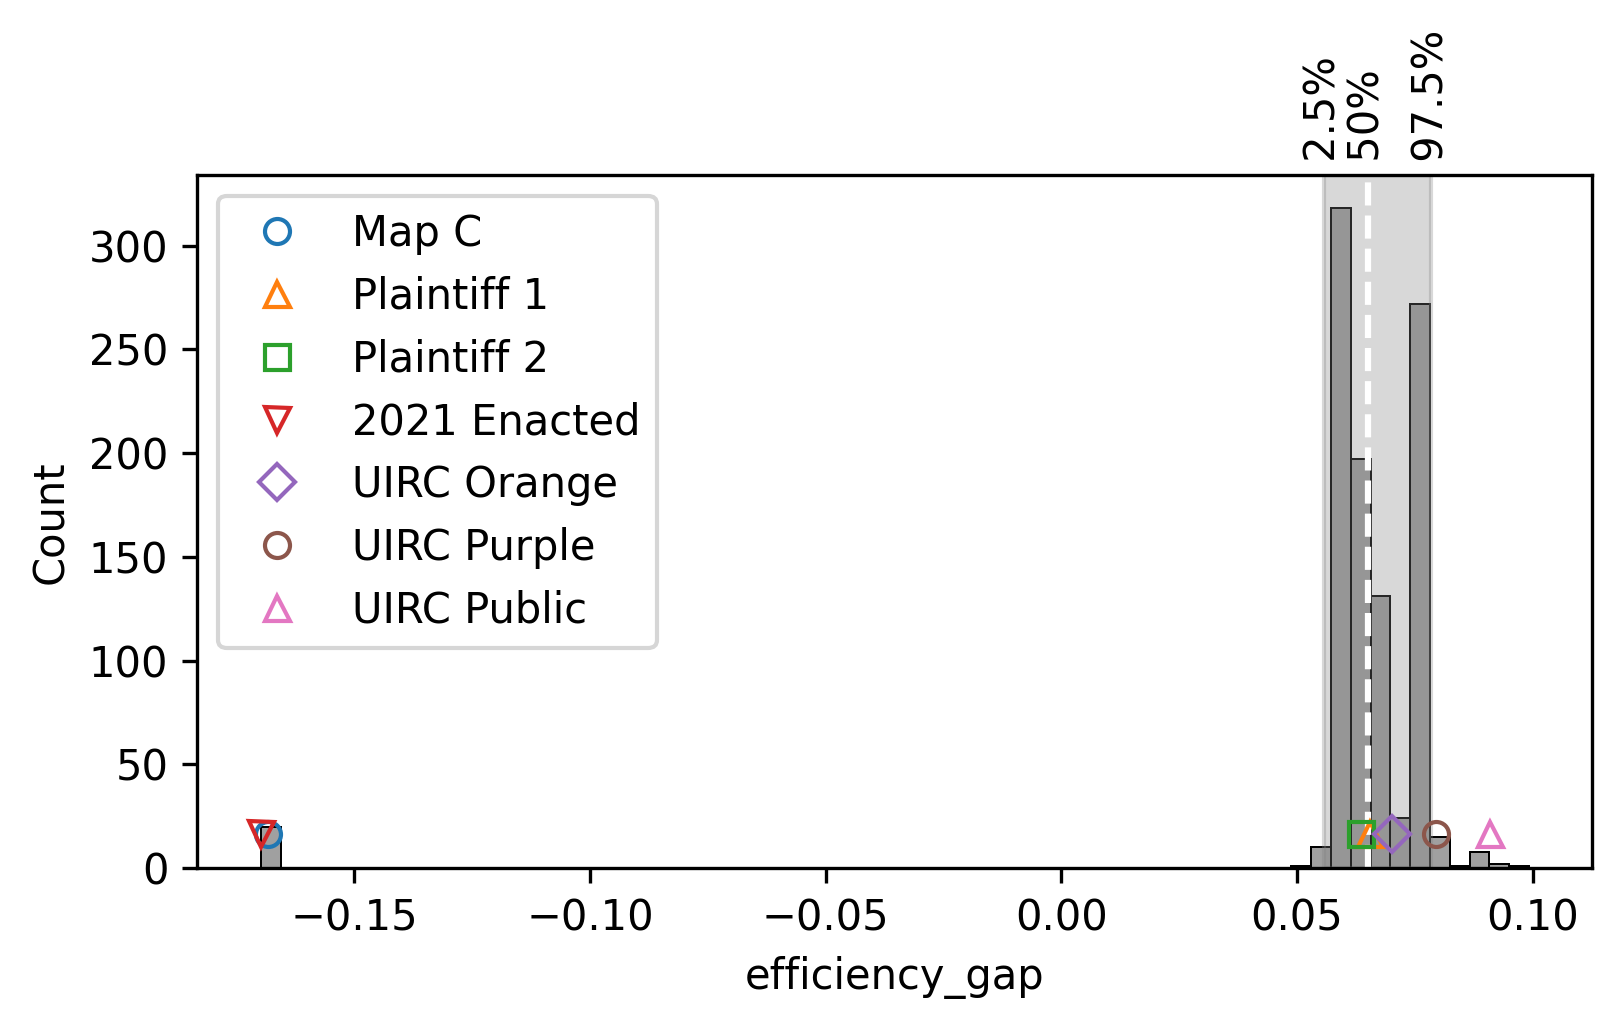

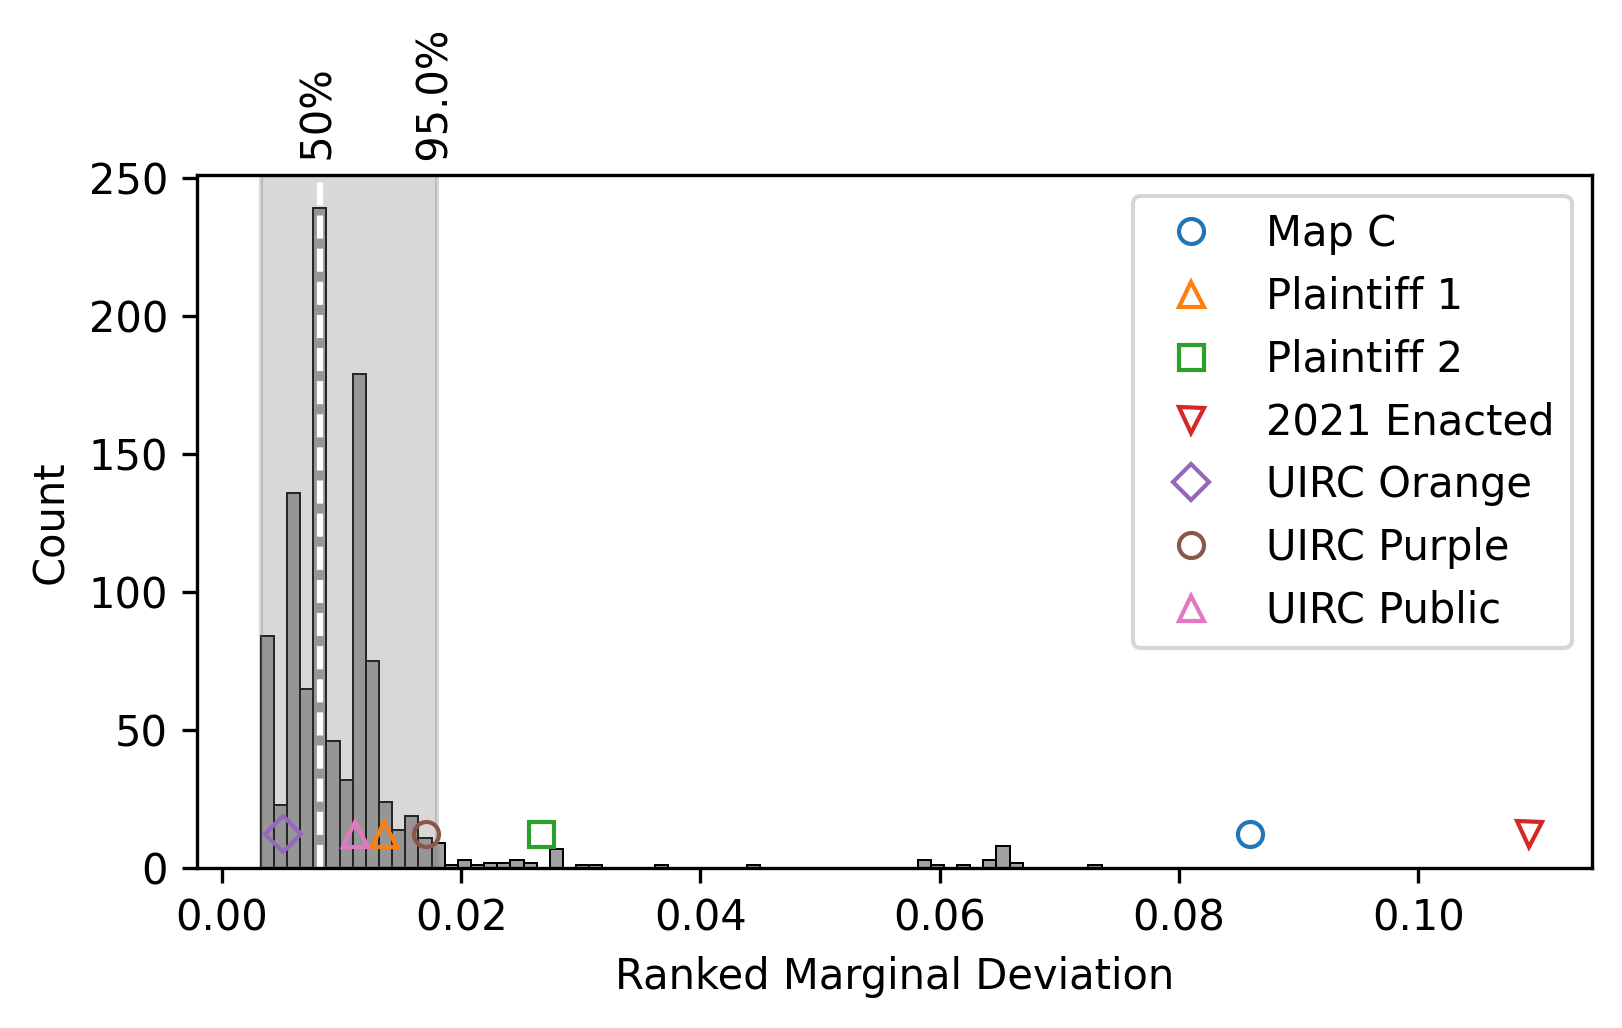

In [7]:
import utgc.results as gcres
import utgc.plotting as gcplt
import matplotlib.pyplot as plt

import json

if "comparison_maps" not in locals():
    with open(f"output/{tag}/ensemble/comparison_maps.json", "r") as f:
        comparison_maps = json.load(f)

output_path = f"output/{tag}/ensemble/output.jsonl"

# Partisan vote shares
party_shares = gcres.read_jsonl_table(output_path, "majority_partisan_shares")
party_shares = gcres.sort_subentries(party_shares, "majority_partisan_shares")

plt.figure(dpi=300, figsize=(6,4))
gcplt.district_plot(
    party_shares,
    reference_values={
        k: sorted(v["majority_partisan_shares"].values()) for k, v in comparison_maps.items()
    },
    relative_to_median=False
)
plt.xlabel("Ranked Partisan Share")
plt.show()

plt.figure(dpi=300, figsize=(6,3))
gcplt.distribution_plot(
    party_shares["majority_partisan_shares_0"],
    highlight_interval=[0.025, 0.975],
    reference_values={
        mapname: min(stats["majority_partisan_shares"].values())
        for mapname, stats in comparison_maps.items()
    },
    relative_to_median=False,
)
plt.xlabel("Least-Republican District")
plt.show()

sdvs = gcres.read_jsonl_table(output_path, "stdev_partisan_share")
plt.figure(dpi=300, figsize=(6,3))
gcplt.distribution_plot(
    sdvs["stdev_partisan_share"],
    highlight_interval=[0.025, 0.975],
    reference_values={
        mapname: stats["stdev_partisan_share"]
        for mapname, stats in comparison_maps.items()
    },
    relative_to_median=False,
)
plt.xlabel("Standard Deviation of Partisan Vote Share")
plt.show()

eg = gcres.read_jsonl_table(output_path, "efficiency_gap")
plt.figure(dpi=300, figsize=(6,3))
gcplt.distribution_plot(
    eg["efficiency_gap"],
    highlight_interval=[0.025, 0.975],
    reference_values={
        mapname: stats["efficiency_gap"]
        for mapname, stats in comparison_maps.items()
    },
    relative_to_median=False,
)
plt.show()

ranked_means = party_shares.mean(axis=0)

def ranked_marginal_deviation(party_shares, ranked_means):
    rmd = ((party_shares - ranked_means) ** 2)
    if isinstance(party_shares, list):
        rmd = rmd.sum()
    else:
        rmd = rmd.sum(axis=1)
    return (rmd / len(ranked_means)) ** 0.5

plt.figure(dpi=300, figsize=(6,3))
gcplt.distribution_plot(
    ranked_marginal_deviation(party_shares, ranked_means),
    reference_values={
        mapname: ranked_marginal_deviation(
            sorted(stats["majority_partisan_shares"].values()),
            ranked_means
        ) for mapname, stats in comparison_maps.items()
    },
    highlight_interval=[0, 0.95],
    relative_to_median=False,
)
plt.xlabel("Ranked Marginal Deviation")
# plt.xlim(left=0)
plt.show()

In [8]:
hashes = gcres.read_jsonl_table(output_path, "assignment_hash")
print(f"Unique maps: {len(hashes.drop_duplicates()) / len(hashes):.1%}")

Unique maps: 89.6%
